In [7]:
import numpy as np
from gnuradio import gr
from gnuradio import blocks
from gnuradio import analog

gr.version()

'3.10.9.2'

Generated 6400 IQ samples for 200 bits.


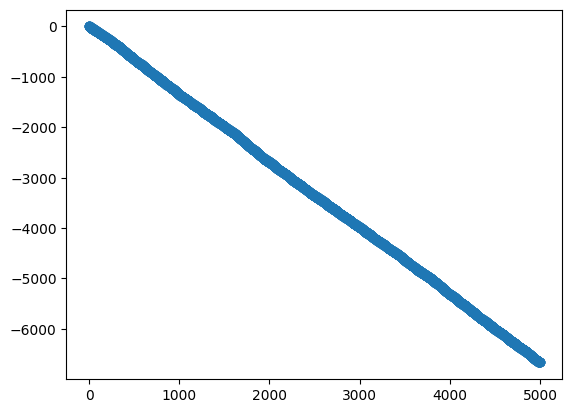

In [32]:
#!/usr/bin/env python3
import numpy as np
from gnuradio import gr, blocks, digital

def fsk_modulate(bit_seq,
                 samp_rate=32000,
                 bit_rate=100,
                 freq_dev_hz=500,
                 bt=1e5):
    """
    Modulate a sequence of bits (0/1) into complex IQ samples using 2-FSK.
    """
    # Derived params
    sps         = int(samp_rate // bit_rate)
    sensitivity = 2 * np.pi * freq_dev_hz / samp_rate

    tb = gr.top_block()

    # 1) Source of raw bits as bytes (0 or 1)
    src = blocks.vector_source_b(list(bit_seq), repeat=False)

    # 2) Throttle so we emit at bit_rate (char size)
    thr = blocks.throttle(gr.sizeof_char, bit_rate, True)

    # 3) GFSK modulator (char → complex)
    mod = digital.gfsk_mod(
        samples_per_symbol=sps,
        sensitivity      = sensitivity,
        bt               = bt,
        verbose=False,
        log=False
    )

    # 4) Capture IQ samples
    sink = blocks.vector_sink_c()

    # Connect: bits → throttle → mod → sink
    tb.connect(src, thr, mod, sink)

    # Run & collect
    tb.run()
    return np.array(sink.data(), dtype=np.complex64)


if __name__ == "__main__":
    # Test
    bits = np.random.randint(0, 2, 200)
    iq = fsk_modulate(bits,
                      samp_rate=1e6,
                      bit_rate=25e4,
                      freq_dev_hz=250e3)
    print(f"Generated {len(iq)} IQ samples for {len(bits)} bits.")


    # Plotting
    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(np.unwrap(np.angle(iq[0:5000])), 'o')
